<a href="https://colab.research.google.com/github/dsaoulis/Thesis/blob/main/SPEARMAN_%26_VIF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

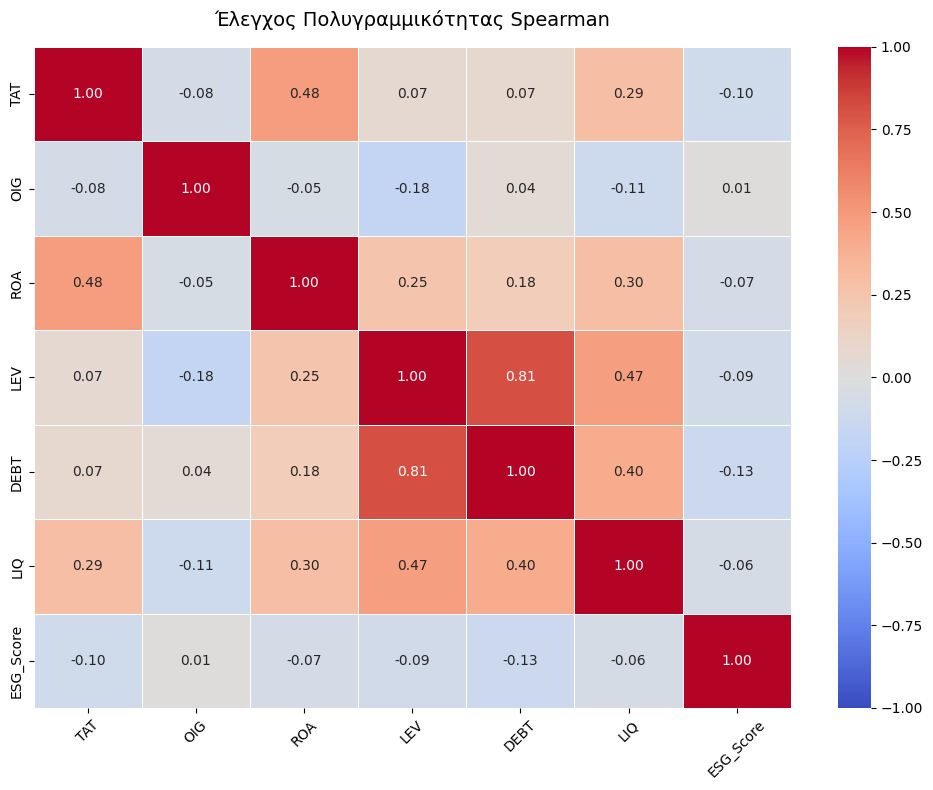

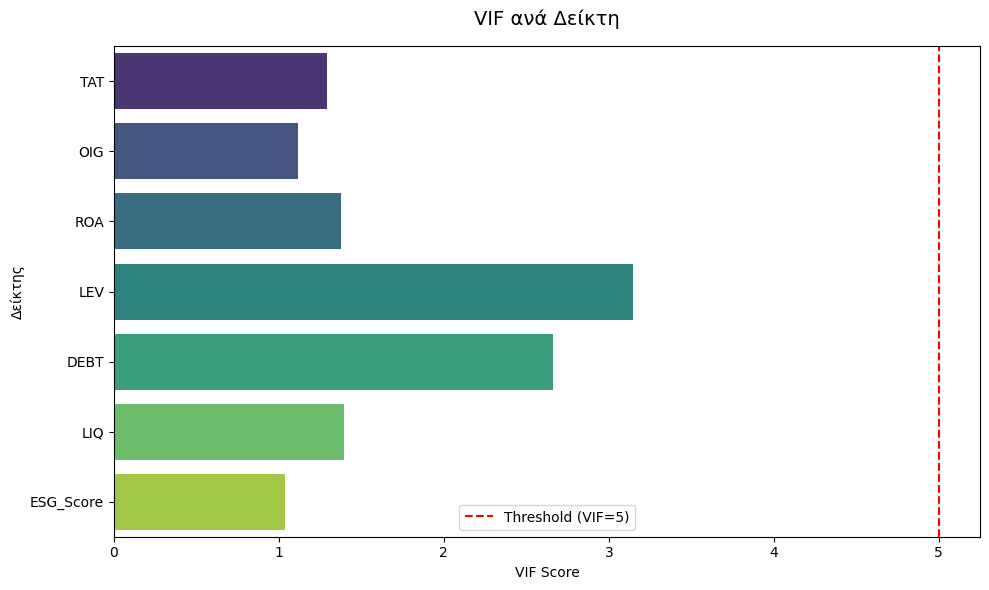

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Φόρτωση Δεδομένων
dropbox_url = "https://www.dropbox.com/scl/fi/ridnctbeg4tdjsr16cbpl/NORMALIZED-INDICATORS.xlsx?rlkey=96fvv6xnnwampnsm6gb1055k7&st=ujqqamyv&dl=1"
df = pd.read_excel(dropbox_url, sheet_name='ΣΥΝΟΛΙΚΑ 3')

# Επιλογή των 7 δεικτών
predictors = ['TAT', 'OIG', 'ROA', 'LEV', 'DEBT', 'LIQ', 'ESG_Score']
df_check = df[predictors].copy().dropna()

# -------- #
# SPEARMAN #
# -------- #
# Υπολογισμός Πίνακα Συσχέτισης Spearman
corr_matrix = df_check.corr(method='spearman')

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title('Έλεγχος Πολυγραμμικότητας Spearman', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- #
# VIF #
# --- #
# Προσθήκη constant για τον σωστό υπολογισμό του VIF
X = sm.add_constant(df_check)

vif_data = pd.DataFrame()
vif_data["Δείκτης"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data[vif_data["Δείκτης"] != "const"]

# Δημιουργία διαγράμματος VIF
plt.figure(figsize=(10, 6))
sns.barplot(data=vif_data, x="VIF", y="Δείκτης",hue="Δείκτης", palette="viridis", legend=False)

# Γραμμή ορίου στο 5
plt.axvline(x=5, color='red', linestyle='--', label='Threshold (VIF=5)')

plt.title('VIF ανά Δείκτη', fontsize=14, pad=15)
plt.xlabel('VIF Score')
plt.legend()
plt.tight_layout()
plt.show()